<a href="https://colab.research.google.com/github/srijamaradana/MACHINE-LEARNING-ASSIGNMENTS/blob/main/SUPPORTVECTOR_MACHINES(EXP_8.6_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
np.random.seed(5)

n = 200

x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(0, 9, n)

label = (x2 > x1**2).astype(int)

data = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'label': label
})

print(data.shape)
data.head()

(200, 3)


,x1,x2,label
0,-1.668041,3.129563,1
1,2.224394,0.115633,0
2,-1.759685,1.490776,0
3,2.511665,0.543298,0
4,-0.069533,2.503403,1


In [3]:
data.isnull().sum()

,0
x1,0
x2,0
label,0


In [4]:
feature_cols = ['x1', 'x2']

x = data[feature_cols]
y = data.label


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=5,
    stratify=y
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(140, 2)

(140,)

(60, 2)

(60,)

In [5]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [6]:
model = SVC(
    kernel='rbf',
    random_state=0
)

model.fit(x_train, y_train)

svm_prediction = model.predict(x_test)

print("svm_prediction:", svm_prediction)

svm_prediction: [0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1
 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 0]


In [7]:
conf_mat = metrics.confusion_matrix(
    y_test,
    svm_prediction
)

print("SVM [kernel - rbf]")
print("Confusion Matrix:\n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svm_prediction
)

print("Accuracy Score:", accuracy_score)

print(
    "Accuracy in Percentage:",
    int(accuracy_score * 100),
    "%"
)

print(
    metrics.classification_report(
        y_test,
        svm_prediction
    )
)

SVM [kernel - rbf]
Confusion Matrix:
 [[20  0]
 [ 3 37]]
Accuracy Score: 0.95
Accuracy in Percentage: 95 %
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       1.00      0.93      0.96        40

    accuracy                           0.95        60
   macro avg       0.93      0.96      0.95        60
weighted avg       0.96      0.95      0.95        60



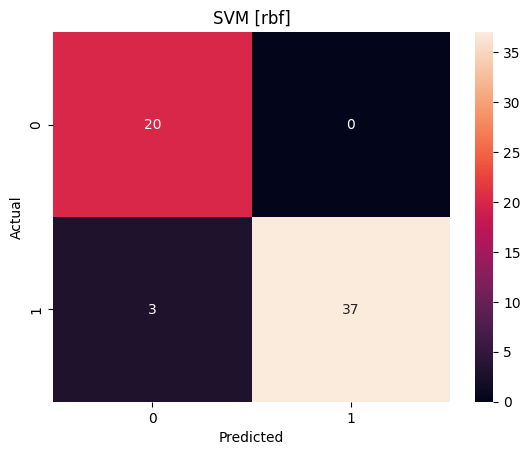

In [8]:
conf_mat = pd.crosstab(
    y_test,
    svm_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(
    conf_mat,
    annot=True
).set(
    title='SVM [rbf]'
)

plt.show()